Optimization Techniques for Autonomous Vehicle Federated Learning
**bold text**
Application: Autonomous Driving Systems
Outcome: Optimized Training Curves

This notebook simulates vehicle sensor clients (LiDAR, camera-derived features, radar) and applies:

✅ Adaptive Learning Rate (Adam)

✅ Momentum (SGD + Momentum)

✅ Weight Decay (L2 Regularization)

✅ Hyperparameter tuning

✅ Optimized training curve comparison

**Federated Learning for Autonomous Vehicles**

Each vehicle acts as an FL client and trains locally on:

Speed

Distance to object

Lane deviation

Radar reflections

Obstacle density

Weather features

Traffic signal status

Road curvature

Task: Binary classification (Safe / Risky driving state)

# **Step 1: Install & Import**

In [1]:
!pip install torch numpy matplotlib scikit-learn

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
import copy

# **Step 2: Simulate Autonomous Vehicle Sensor Dataset**

In [3]:
# Simulate vehicle sensor dataset
X, y = make_classification(
    n_samples=15000,
    n_features=25,      # Vehicle sensor features
    n_informative=18,
    n_classes=2,
    random_state=42
)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

# **Step 3: Create Non-IID Vehicle Clients**

Each vehicle experiences different road conditions.

In [4]:
def create_vehicle_clients(X, y, num_clients=8):
    clients = []

    for i in range(num_clients):
        # Simulate different driving environments
        idx = np.random.choice(range(len(X)), size=1500, replace=False)
        clients.append((X[idx], y[idx]))

    return clients

clients = create_vehicle_clients(X, y)

# **Step 4: Define Autonomous Vehicle Model**

In [5]:
class AVModel(nn.Module):
    def __init__(self):
        super(AVModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(25, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

# **Step 5: Local Training with Optimization Techniques**

We implement:

1. SGD + Momentum

2. Adam (adaptive learning rate)

3. Weight Decay

In [6]:
def local_train(model, data, optimizer_type="sgd", lr=0.01,
                momentum=0.9, weight_decay=0.0001, epochs=3):

    model.train()
    X, y = data

    if optimizer_type == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr,
                              momentum=momentum,
                              weight_decay=weight_decay)
    elif optimizer_type == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr,
                               weight_decay=weight_decay)

    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

    return model.state_dict()

# **Step 6: Federated Averaging**

In [7]:
def fedavg(global_model, client_states):
    global_dict = global_model.state_dict()

    for key in global_dict.keys():
        global_dict[key] = torch.mean(
            torch.stack([client_states[i][key]
                         for i in range(len(client_states))]),
            dim=0
        )

    global_model.load_state_dict(global_dict)
    return global_model

# **Step 7: Federated Training Loo**p

In [8]:
def federated_training(clients, optimizer_type="sgd",
                       lr=0.01, momentum=0.9,
                       weight_decay=0.0001, rounds=20):

    global_model = AVModel()
    acc_list = []

    for r in range(rounds):
        client_states = []

        for client_data in clients:
            local_model = copy.deepcopy(global_model)
            updated_state = local_train(local_model,
                                        client_data,
                                        optimizer_type,
                                        lr,
                                        momentum,
                                        weight_decay)
            client_states.append(updated_state)

        global_model = fedavg(global_model, client_states)

        # Evaluate
        global_model.eval()
        with torch.no_grad():
            preds = global_model(X).argmax(dim=1)
            acc = accuracy_score(y.numpy(), preds.numpy())
            acc_list.append(acc)

        print(f"Round {r+1}, Accuracy: {acc:.4f}")

    return acc_list

Step 8: Hyperparameter Tuning

Compare:

1. SGD

2. SGD + Momentum

3. Adam

In [9]:
print("Training with SGD...")
sgd_acc = federated_training(clients,
                             optimizer_type="sgd",
                             lr=0.01,
                             momentum=0.0)

print("\nTraining with SGD + Momentum...")
momentum_acc = federated_training(clients,
                                  optimizer_type="sgd",
                                  lr=0.01,
                                  momentum=0.9)

print("\nTraining with Adam...")
adam_acc = federated_training(clients,
                              optimizer_type="adam",
                              lr=0.001)

Training with SGD...
Round 1, Accuracy: 0.4970
Round 2, Accuracy: 0.5140
Round 3, Accuracy: 0.5391
Round 4, Accuracy: 0.5618
Round 5, Accuracy: 0.5779
Round 6, Accuracy: 0.5910
Round 7, Accuracy: 0.6053
Round 8, Accuracy: 0.6188
Round 9, Accuracy: 0.6299
Round 10, Accuracy: 0.6409
Round 11, Accuracy: 0.6483
Round 12, Accuracy: 0.6553
Round 13, Accuracy: 0.6621
Round 14, Accuracy: 0.6699
Round 15, Accuracy: 0.6752
Round 16, Accuracy: 0.6819
Round 17, Accuracy: 0.6901
Round 18, Accuracy: 0.6957
Round 19, Accuracy: 0.7014
Round 20, Accuracy: 0.7075

Training with SGD + Momentum...
Round 1, Accuracy: 0.5643
Round 2, Accuracy: 0.5990
Round 3, Accuracy: 0.6231
Round 4, Accuracy: 0.6371
Round 5, Accuracy: 0.6497
Round 6, Accuracy: 0.6631
Round 7, Accuracy: 0.6739
Round 8, Accuracy: 0.6829
Round 9, Accuracy: 0.6925
Round 10, Accuracy: 0.7018
Round 11, Accuracy: 0.7085
Round 12, Accuracy: 0.7152
Round 13, Accuracy: 0.7216
Round 14, Accuracy: 0.7275
Round 15, Accuracy: 0.7332
Round 16, Accuracy:


# **Step 9: Optimized Training Curves**



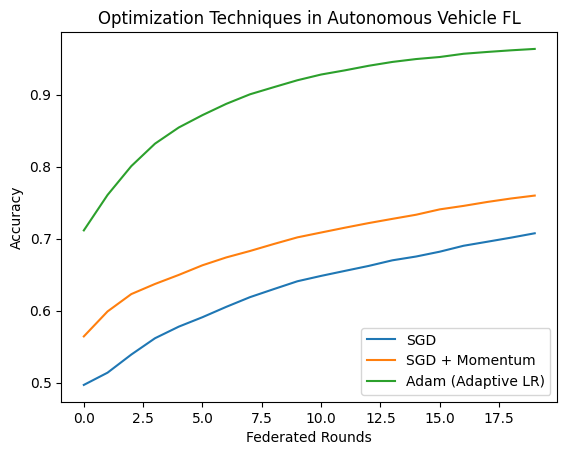

In [10]:
plt.plot(sgd_acc, label="SGD")
plt.plot(momentum_acc, label="SGD + Momentum")
plt.plot(adam_acc, label="Adam (Adaptive LR)")
plt.xlabel("Federated Rounds")
plt.ylabel("Accuracy")
plt.title("Optimization Techniques in Autonomous Vehicle FL")
plt.legend()
plt.show()